<a href="https://colab.research.google.com/github/seokjinwoo/AiandEcon_2026/blob/main/lec_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Shrinkage method
# features 를 줄여서 과적합을 방지함
# Ridge & Lasso Regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score


from mlxtend.feature_selection import SequentialFeatureSelector as SFS


Hitters = pd.read_csv('/content/Hitters.csv')
Hitters.head()


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [ ]:
# pre-processing 전처리

# 결측치 버려
Hitters = Hitters.dropna()
Hitters.head()

# One-hot-encoding
# 범주형 변수를 범주의 값마다 더미변수를 생성
df = pd.get_dummies(Hitters, drop_first=True)
# df.head()

In [ ]:
# y(target, label), X(특성변수 정의)
# supervised learning
y = df['Salary']
X = df.drop(columns=['Salary'])





In [ ]:
# train/test data split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


In [ ]:
## Ridge regression
## 계수의 제곱의 합이 패널티로 들어감

## 특성변수를 평균 0, 표준편차 1로 표준화 시켜야 잘 작동함
## 특성변수의 평균을 빼고, 표준편차로 나눈다

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [ ]:
## train 데이터로
## Ridge model을 이용해서 훈련
ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(X_train_scaled, y_train)

# test 데이터로 모형의 MSE를 계산
ridge_model.predict(X_test_scaled)
y_pred = ridge_model.predict(X_test_scaled)
mse_ridge = mean_squared_error(y_test, y_pred)

print("Ridge MSE: ", mse_ridge)


Ridge MSE:  137400.762252678


In [ ]:
## lambda selection
## tuning of hyper-parameter
## for many lambdas, choose the optimal one
lambda_values = np.logspace(-3,1,100)

cv_mse_scores = []

# 5-fold CV을 통해서 mse를 계산
for alpha in lambda_values:
  ridge_model = Ridge(alpha = alpha)
  mse_scores = -np.mean(cross_val_score(ridge_model,
                                        X_train_scaled, y_train,
                                        scoring='neg_mean_squared_error', cv=5))
  cv_mse_scores.append(mse_scores)



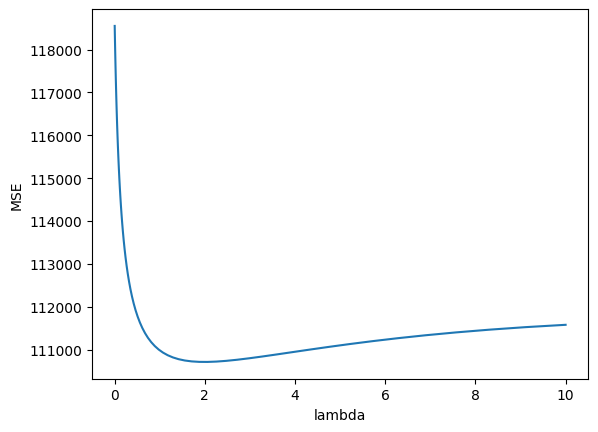

In [ ]:
import matplotlib.pyplot as plt
plt.plot(lambda_values, cv_mse_scores)
plt.xlabel('lambda')
plt.ylabel('MSE')
plt.show()

In [ ]:
# mse가 가장 작아지는 lambda는?
optimal_lambda = lambda_values[np.argmin(cv_mse_scores)]
print("Optimal lambda (Ridge): ", optimal_lambda)

Optimal lambda (Ridge):  2.0565123083486534


## 분류 (classification)

- $y$가 질적인 값을 때가 있음. 이산적(discrete)인 경우
- 눈의 색: 검정, 갈색, 파랑
- 경제활동: {경제활동참가, 미참가},{참가, 미참가(육아, 그냥 쉬었음,..)}
- 이메일: {정상(ham), 스팸(spam)}

- 두 가지 중 하나로 분류: binary choice model

- $y \in \{ 0, 1\}$, 관심 있는 선택을 하면 1, 아니면 0

- $X$ 가 주어졌을 때 $\Pr(y=1 | X)$ 조건부 확률








In [ ]:
## 파산확률 추정(신용평가모형)

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/Default.csv')
# df.tail()




In [ ]:
# 간단한 전처리
df['Default'] = df['Default']
# df['Default'].describe()
# 가로축: balance, 세로축: salary
# df['Default'] 값에 따라서 다르게 시각화






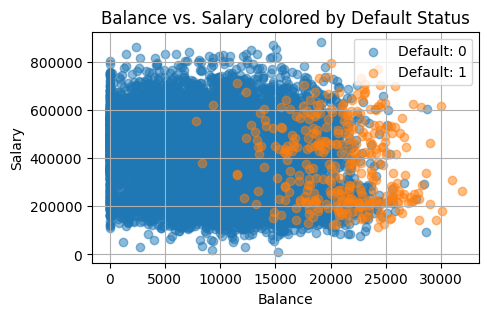

In [ ]:
plt.figure(figsize=(5, 3))
for default_status in df['Default'].unique():
    subset = df[df['Default'] == default_status]
    plt.scatter(subset['Bank Balance'], subset['Annual Salary'], label=f'Default: {default_status}', alpha=0.5)

plt.xlabel('Balance')
plt.ylabel('Salary')
plt.title('Balance vs. Salary colored by Default Status')
plt.legend()
plt.grid(True)
plt.show()

## 로지스틱 회귀모형 (logistic regression)

- $X$가 주어졌을 때, $Y$를 0으로 배정할 것인지 아니면 1로 배정할 것인지

- $\Pr(Y=1|X)$ 이 조건부 확률이 중요하다.

- balance가 주어졌을 때, 부도가 날 확률.



In [ ]:
# 가로축에는 balance를 세로축에는 default를 표시하는 산포도


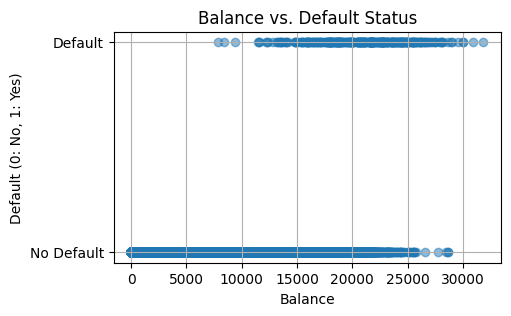

In [ ]:
plt.figure(figsize=(5, 3))
plt.scatter(df['Bank Balance'], df['Default'], alpha=0.5)
plt.xlabel('Balance')
plt.ylabel('Default (0: No, 1: Yes)')
plt.title('Balance vs. Default Status')
plt.yticks([0, 1], ['No Default', 'Default'])
plt.grid(True)

plt.show()

 $$
 \Pr(Y=1|X) = p(X) = \frac{1}{1 + \exp(-(\beta_0 + \beta_1 X))}
 $$

 - log odd-ratio
 $$
 \log \frac{p(X)}{1-p(X)} = \beta_0 + \beta_1 X
 $$


